In [1]:
from trainer import PPOTrainer, PPOConfig
from turan_env_c import CEnv, CHECKER_C3
from policies import make_policy
from profiler import PPOProfiler

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [28]:
n = 20
num_envs = 2048
checker_id = CHECKER_C3
n_steps = 64
n_epochs = 10
batch_size = 2048
lr = 1e-7
gamma = 0.99
gae_lambda = 0.95
clip_eps = 0.2
vf_coef = 0.5
ent_coef = 0.01
max_grad_norm = 0.5
n_outer_steps = 300
total_steps = n_outer_steps * n_steps * num_envs
device = "cuda"
is_compile = True
log_interval = 10
save_interval = 100
checkpoint_dir = "./checkpoints"
run_name = "n20_c3_mlp_featured"

hidden_dim = 256
n_layers   = 3

env    = CEnv(n=n, num_envs=num_envs, checker_id=checker_id)
policy = make_policy("mlp_featured", hidden_dim=hidden_dim, n_layers=n_layers,
                     obs_dim=env.num_actions, action_dim=env.num_actions)
config = PPOConfig(n_steps, n_epochs, batch_size, lr, gamma, gae_lambda,
                   clip_eps, vf_coef, ent_coef, max_grad_norm, total_steps,
                   device, is_compile, log_interval, save_interval, checkpoint_dir, run_name)


In [29]:
trainer = PPOTrainer(env, policy, config=config)
trainer.fit(resume = f"{checkpoint_dir}/{run_name}_final.pt")
env.close()

Loaded ./checkpoints/n20_c3_mlp_featured_final.pt  iter=200  steps=26,214,400  best=81.55

PPO  n=20  envs=2048  checker=0  device=cuda
policy: MLPFeaturedPolicy  params: 701,887
transitions/update: 131,072  total iters: 300
checkpoints: ./checkpoints/n20_c3_mlp_featured_*.pt

200 steps x 2048 envs in 0.01s
  77,593,014 steps/sec
  77.59M steps/sec


iter   210 | steps 27.53M | fps 81,333 | ret 76.20 | best 81.55 | pg -0.0270 | vf 2.656 | ent 3.332 | clip 0.409 | t 16s
iter   220 | steps 28.84M | fps 90,463 | ret 61.45 | best 81.55 | pg -0.0498 | vf 41.646 | ent 3.222 | clip 0.278 | t 31s
iter   230 | steps 30.15M | fps 93,211 | ret 78.43 | best 81.55 | pg -0.0305 | vf 1.427 | ent 2.912 | clip 0.419 | t 46s
iter   240 | steps 31.46M | fps 81,952 | ret 75.00 | best 81.55 | pg -0.0373 | vf 15.940 | ent 3.032 | clip 0.260 | t 61s
iter   250 | steps 32.77M | fps 85,114 | ret 76.40 | best 81.55 | pg -0.0397 | vf 2.737 | ent 3.002 | clip 0.426 | t 76s
iter   260 | steps 34.08M | fps 95,144 | ret 75.82 | best 81.55 | pg -0.0410 | vf 11.588 | ent 3.044 | clip 0.376 | t 91s
iter   270 | steps 35.39M | fps 77,542 | ret 64.63 | best 81.55 | pg -0.0612 | vf 24.477 | ent 3.070 | clip 0.409 | t 106s
iter   280 | steps 36.70M | fps 92,548 | ret 66.37 | best 81.55 | pg -0.0609 | vf 24.851 | ent 2.988 | clip 0.372 | t 122s
iter   290 | steps 38.01M

In [30]:
from evaluate import load_policy, best_of_k, draw_graph, compare_k

In [ ]:
ckpt_path    = f"{checkpoint_dir}/{run_name}_91.pt"
policy_name  = "mlp_featured"
policy_kwargs = dict(hidden_dim=hidden_dim, n_layers=n_layers)
eval_n       = 20
eval_checker = checker_id
eval_k       = 1024

Loaded ./checkpoints/n20_c3_mlp_featured_final.pt  step=39,321,600  best_ret=81.55
best_of_1024: 85 edges  (min=85, mean=85.0, max=85)


<Axes: title={'center': 'C3-free  n=20  edges=85'}>

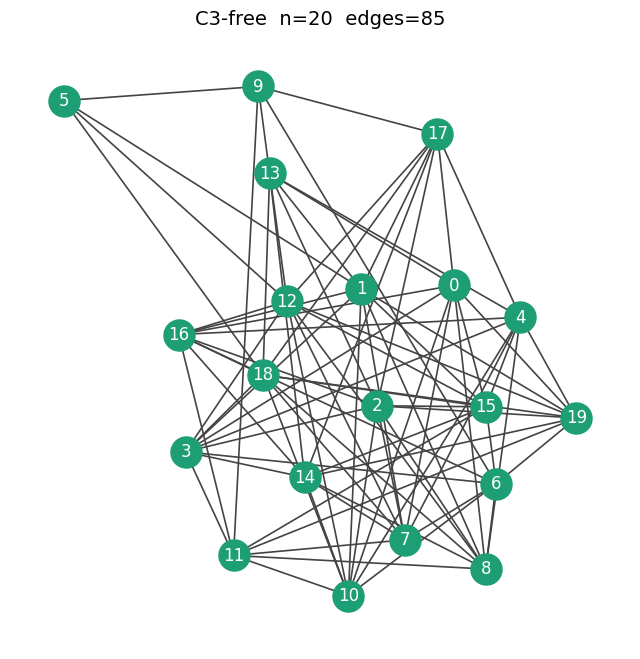

In [35]:
policy_eval, info = load_policy(ckpt_path, policy_name, **policy_kwargs)
obs, edges, G = best_of_k(policy_eval, eval_n, eval_checker, k=eval_k)
draw_graph(G, title=f"{'C3' if eval_checker==0 else 'C4'}-free  n={eval_n}  edges={edges}")

In [33]:
compare_k(policy_eval, eval_n, eval_checker, ks=(1, 8, 32, 128, 512))


     k    best      mean     min     max
------------------------------------------
     1      91      91.0      91      91
     8      91      91.0      91      91


    32      91      91.0      91      91
   128      91      91.0      91      91
   512      91      91.0      91      91
